In [1]:
import yfinance as yf
import talib
import pynance as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

# 2. Import your custom module!
from src.data_loader import load_data

# 3. Define the path to your massive CSV file
file_path = '../data/raw/raw_analyst_ratings.csv'

# 4. Run your custom function
df = load_data(file_path)

# 5. Display the top 5 rows
if df is not None:
    display(df.head())

2026-05-09 02:34:27,850 - INFO - Attempting to load data from: ../data/raw/raw_analyst_ratings.csv
2026-05-09 02:34:31,353 - INFO - Success! Loaded 1407328 rows and 6 columns.


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"yfinance version: {yf.__version__}")
print(f"TA-Lib version: {talib.__version__}")

yfinance version: 1.3.0
TA-Lib version: 0.6.8


**Descriptive Statistics**


Obtain basic statistics for textual lengths (e.g., headline character count
distribution)

2026-05-09 02:34:31,495 - INFO - Calculating text lengths for column: 'headline'
2026-05-09 02:34:32,077 - INFO - Headline lengths calculated successfully.


--- Headline Length Statistics ---


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

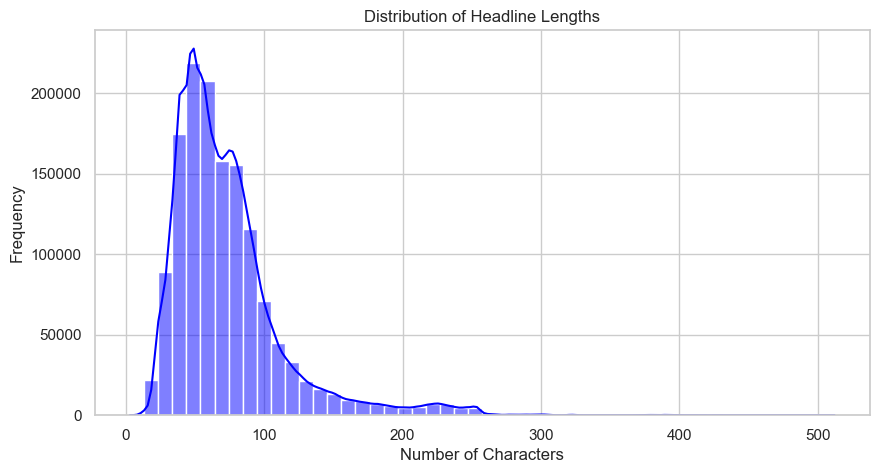

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Import your brand new module!
from src.eda_analysis import calculate_headline_lengths

# 2. Set a clean style for our graphs
sns.set_theme(style="whitegrid")

# 3. Use your custom function to calculate lengths
df = calculate_headline_lengths(df, column_name='headline')

# 4. Print the Descriptive Statistics (Mean, Min, Max, etc.)
print("--- Headline Length Statistics ---")
display(df['headline_length'].describe())

# 5. Plot the Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

b. Count articles per publisher to identify which sources are most active


2026-05-09 02:36:13,977 - INFO - Unifying publishers and extracting companies from emails...


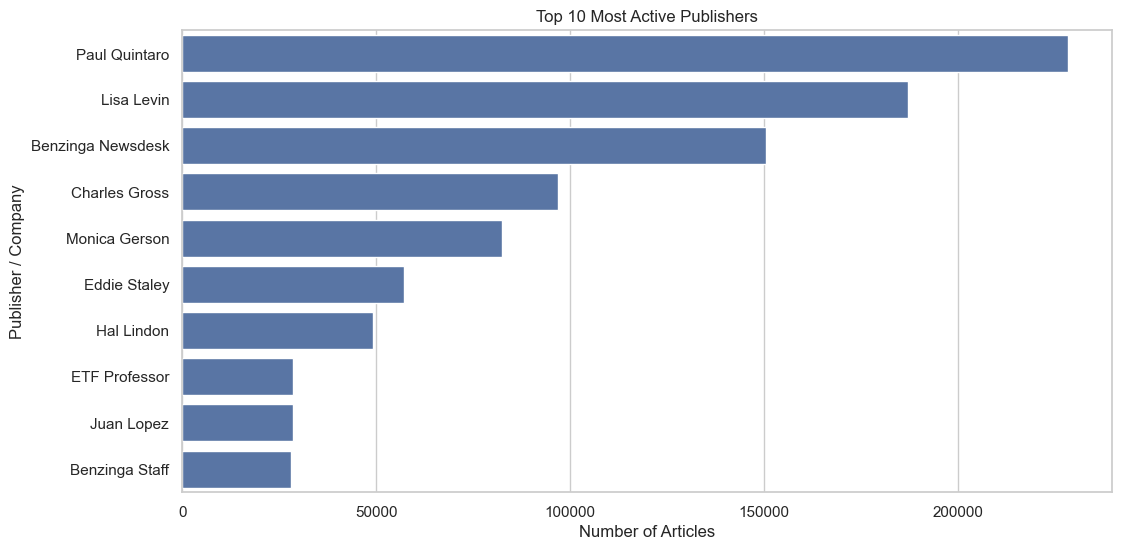

In [7]:
# 1. Import your new unifying function
from src.eda_analysis import get_unified_publishers

# 2. Run the function to create the 'unified_publisher' column
df = get_unified_publishers(df)

# 3. Count the top 10 from this new, clean column
top_unified = df['unified_publisher'].value_counts().head(10)

# 4. Plot the ultimate, unified bar chart (Emails & Names Unified)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_unified.values, y=top_unified.index)
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher / Company')
plt.show()

Analyze publication dates to identify trends over time — are there spikes in
news volume around specific market events?

2026-05-09 02:44:33,370 - INFO - Calculating daily publication trends...
2026-05-09 02:44:33,640 - INFO - Time-series aggregation complete.


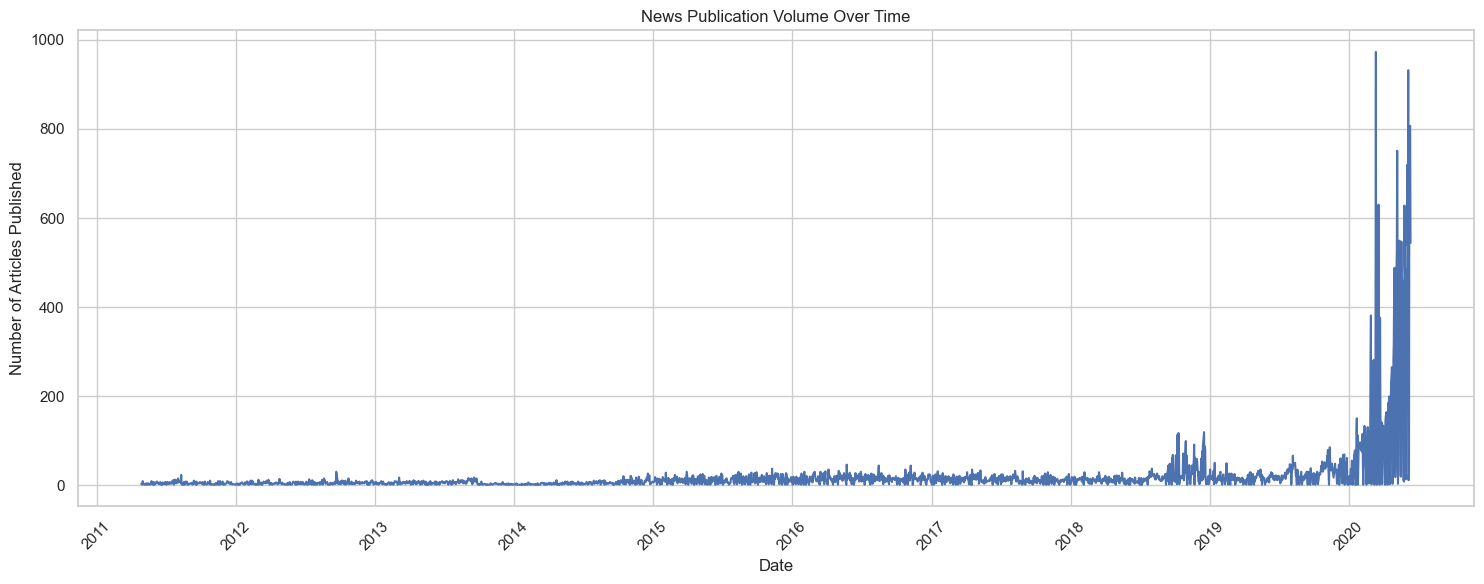

--- Top 5 Days with the Most News ---


just_date
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
dtype: int64

In [9]:
# 1. Import the new time-series function
from src.eda_analysis import get_publication_trends

# 2. Run the function to get our daily counts
daily_trends = get_publication_trends(df)

# 3. Plot the Time-Series line chart
plt.figure(figsize=(15, 6))
sns.lineplot(x=daily_trends.index, y=daily_trends.values)
plt.title('News Publication Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles Published')
plt.xticks(rotation=45)
plt.tight_layout() # This keeps the dates from overlapping
plt.show()

# 4. Print the exact dates of the biggest spikes!
print("--- Top 5 Days with the Most News ---")
display(daily_trends.sort_values(ascending=False).head(5))

**3. Text Analysis (Topic Modeling)**

Use NLP techniques to identify common keywords and phrases in
headlines

b. Extract significant topics or recurring themes (e.g., "FDA approval", "price
target", "earnings beat")


2026-05-09 02:59:35,479 - INFO - Extracting top 15 phrases (n-gram=1) from 'headline'...
2026-05-09 02:59:55,755 - INFO - Keyword extraction complete.
2026-05-09 02:59:55,810 - INFO - Extracting top 15 phrases (n-gram=2) from 'headline'...
2026-05-09 03:00:57,535 - INFO - Keyword extraction complete.


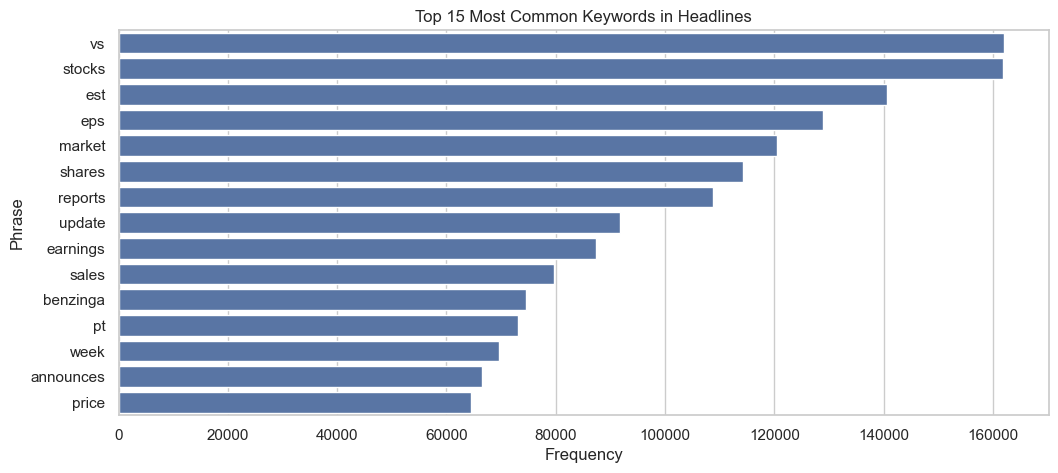

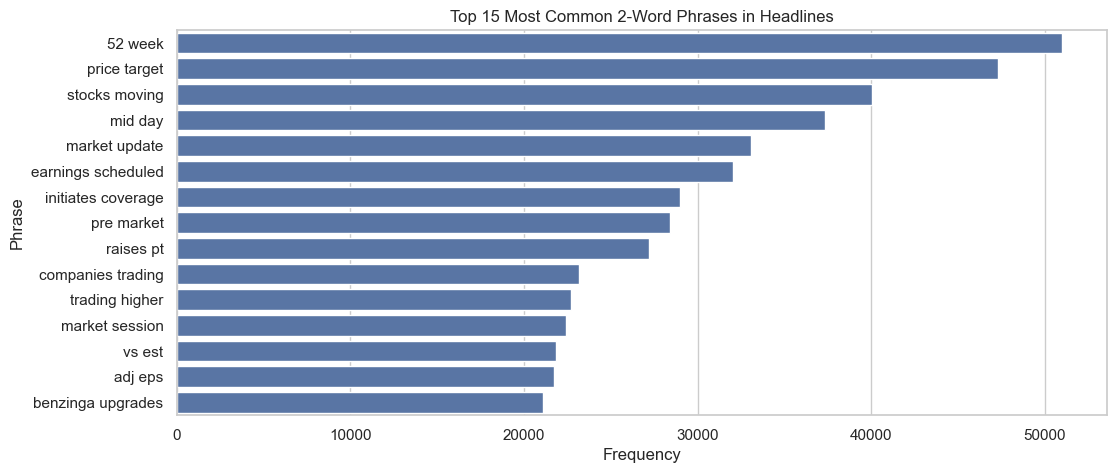

In [12]:
# 1. Import your new function
from src.nlp_analysis import get_top_keywords_and_phrases

# 2. Extract single words (Keywords)
top_keywords = get_top_keywords_and_phrases(df, column_name='headline', n_gram=1, top_n=15)

# 3. Extract two-word phrases (Bigrams)
top_phrases = get_top_keywords_and_phrases(df, column_name='headline', n_gram=2, top_n=15)

# 4. Plot the Keywords
plt.figure(figsize=(12, 5))
sns.barplot(data=top_keywords, x='Frequency', y='Phrase')
plt.title('Top 15 Most Common Keywords in Headlines')
plt.show()

# 5. Plot the Phrases
plt.figure(figsize=(12, 5))
sns.barplot(data=top_phrases, x='Frequency', y='Phrase')
plt.title('Top 15 Most Common 2-Word Phrases in Headlines')
plt.show()

Analyze publishing times; is there a specific time of day when most news is
released?


2026-05-09 04:00:45,329 - INFO - Calculating publication frequency by time of day...
2026-05-09 04:00:45,364 - INFO - Hourly time-series aggregation complete.
2026-05-09 04:00:45,401 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 04:00:45,421 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


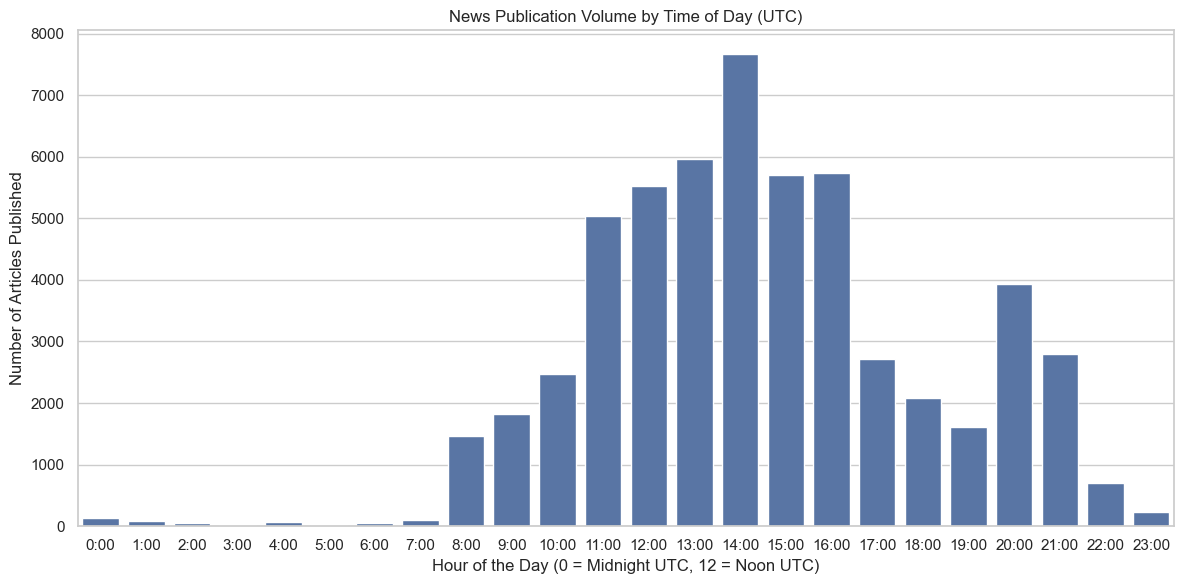

In [14]:
# 1. Import your new time-of-day function
from src.eda_analysis import get_publishing_times

# 2. Run the function to get the hourly counts
hourly_trends = get_publishing_times(df)

# 3. Plot the 24-Hour Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_trends.index, y=hourly_trends.values)

# Make the chart look professional
plt.title('News Publication Volume by Time of Day (UTC)')
plt.xlabel('Hour of the Day (0 = Midnight UTC, 12 = Noon UTC)')
plt.ylabel('Number of Articles Published')

# Add custom x-axis labels to make it easier to read
plt.xticks(ticks=range(0, 24), labels=[f"{h}:00" for h in range(0, 24)])
plt.tight_layout()
plt.show()

**Publisher Analysis**

a. Identify the most active publishers and characterize their coverage
b. If email addresses are used as publisher names, extract unique domains to
analyze organizational contribution patterns


In [15]:
# 1. Import your custom functions
from src.eda_analysis import get_unified_publishers, characterize_top_publishers

# 2. Extract domains and unify the publisher names (Solves Part 5b)
df = get_unified_publishers(df, column_name='publisher')

# 3. Characterize the coverage of the top 5 publishers (Solves Part 5a)
publisher_profile = characterize_top_publishers(df, publisher_col='unified_publisher', stock_col='stock', top_n=5)

# 4. Display the clean profile table
print("--- Top 5 Publisher Profiles ---")
display(publisher_profile)

2026-05-09 04:04:49,633 - INFO - Unifying publishers and extracting companies from emails...
2026-05-09 04:04:50,351 - INFO - Characterizing coverage for the top 5 publishers...
2026-05-09 04:04:56,253 - INFO - Publisher characterization complete.


--- Top 5 Publisher Profiles ---


,Publisher,Total Articles,Most Covered Stock,Avg Headline Length
0,Paul Quintaro,228373,XRT,84.3
1,Lisa Levin,186979,GPRO,47.5
2,Benzinga Newsdesk,150484,EWW,114.7
3,Charles Gross,96732,GREK,81.0
4,Monica Gerson,82380,AA,51.0
